In [84]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [85]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

In [86]:
df = pd.read_csv('/content/drive/MyDrive/Bank_LG_PROB/bank-full.csv', sep=';')

print("=" * 60)
print("  BANK MARKETING DATASET — EDA REPORT")
print("=" * 60)
print("\nDataset Overview")
print(f"   Rows      : {df.shape[0]:,}")
print(f"   Columns   : {df.shape[1]}")
print(f"   Num cols  : {df.select_dtypes(include='number').shape[1]}")
print(f"   Cat cols  : {df.select_dtypes(exclude='number').shape[1]}")
print(f"   Duplicates: {df.duplicated().sum()}")
print(f"   Nulls     : {df.isnull().sum().sum()}")

print("\n   Column dtypes:")
print(df.dtypes.to_string())


  BANK MARKETING DATASET — EDA REPORT

Dataset Overview
   Rows      : 45,211
   Columns   : 17
   Num cols  : 7
   Cat cols  : 10
   Duplicates: 0
   Nulls     : 0

   Column dtypes:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object


In [87]:
print("\n Target Variable Distribution")
vc = df['y'].value_counts()
print(vc)
imbalance_ratio = vc['no'] / vc['yes']
print(f"\n    Imbalance Ratio (no:yes) = {imbalance_ratio:.1f}:1")




 Target Variable Distribution
y
no     39922
yes     5289
Name: count, dtype: int64

    Imbalance Ratio (no:yes) = 7.5:1


In [114]:
print("\nNumerical Feature Stats")
num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
print(df[num_cols].describe().round(2).to_string())



Numerical Feature Stats
            age   balance  duration  campaign     pdays  previous
count  45211.00  45211.00  45211.00  45211.00  45211.00   45211.0
mean      40.94    933.71    234.94      2.39     41.02       0.0
std       10.62   1176.77    176.75      1.60     99.79       0.0
min       18.00  -1962.00      0.00      1.00      0.00       0.0
25%       33.00     72.00    103.00      1.00      0.00       0.0
50%       39.00    448.00    180.00      2.00      0.00       0.0
75%       48.00   1428.00    319.00      3.00      0.00       0.0
max       95.00   3462.00    643.00      6.00    871.00       0.0


In [89]:
print("\nCategorical Columns")
cat_cols = ['job','marital','education','default','housing','loan',
            'contact','month','poutcome']
for c in cat_cols:
    vc2 = df[c].value_counts()
    print(f"\n   [{c}] ({len(vc2)} unique)")
    print(vc2.to_string(header=False))


Categorical Columns

   [job] (12 unique)
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288

   [marital] (3 unique)
married     27214
single      12790
divorced     5207

   [education] (4 unique)
secondary    23202
tertiary     13301
primary       6851
unknown       1857

   [default] (2 unique)
no     44396
yes      815

   [housing] (2 unique)
yes    25130
no     20081

   [loan] (2 unique)
no     37967
yes     7244

   [contact] (3 unique)
cellular     29285
unknown      13020
telephone     2906

   [month] (12 unique)
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214

   [poutcome] (4 unique)
unknown    36959
failure     4901
other       1840
success     1511


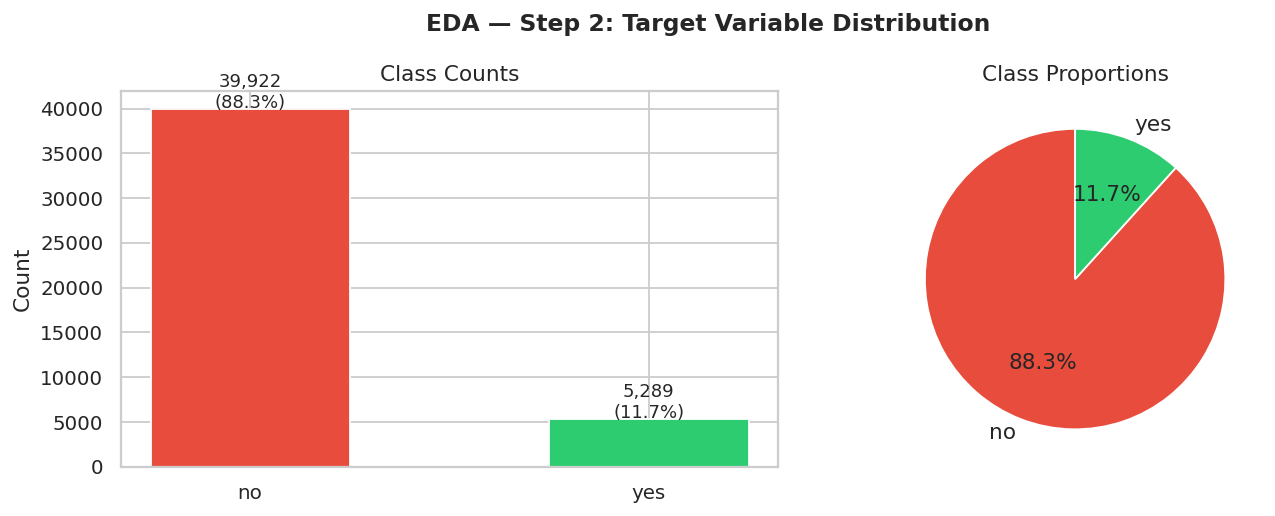

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("EDA — Step 2: Target Variable Distribution", fontsize=13, fontweight='bold')

counts = df['y'].value_counts()
bars = axes[0].bar(counts.index, counts.values, color=['#e74c3c','#2ecc71'], edgecolor='white', width=0.5)
axes[0].set_title("Class Counts")
axes[0].set_ylabel("Count")
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

axes[1].pie(counts.values, labels=counts.index, colors=['#e74c3c','#2ecc71'],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title("Class Proportions")

plt.tight_layout()
plt.show()
plt.close()


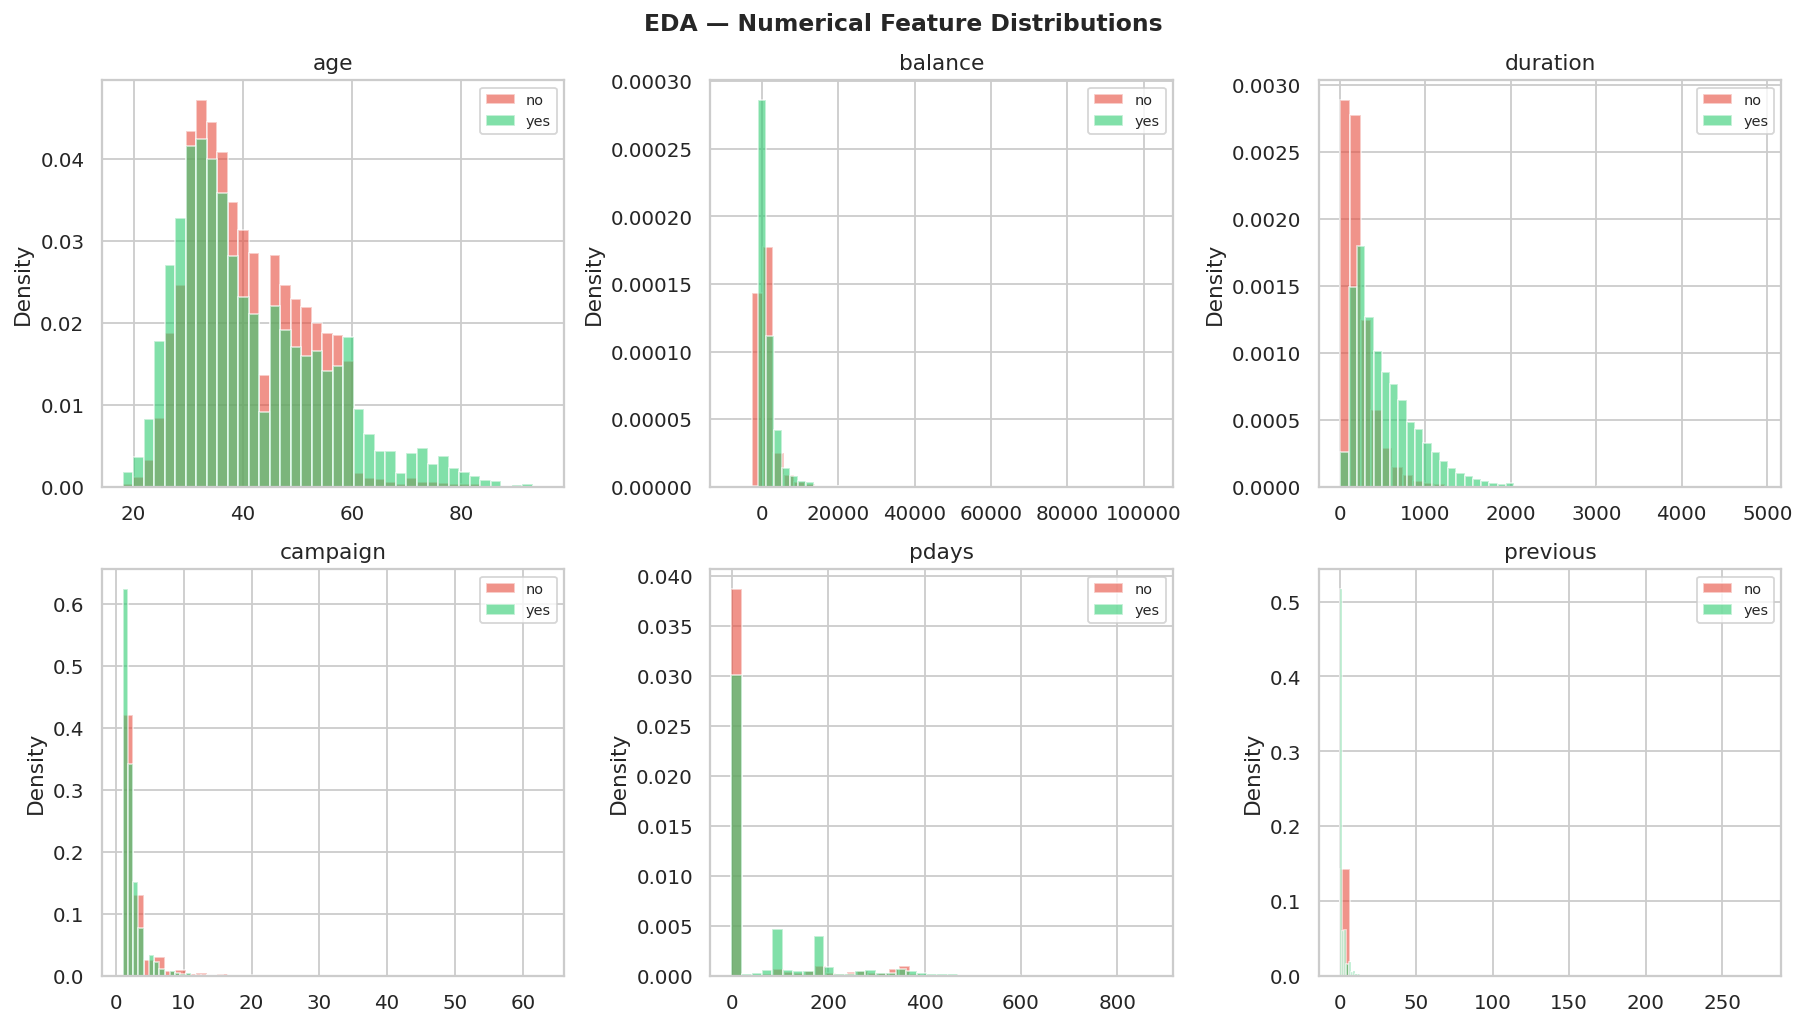

In [91]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("EDA — Numerical Feature Distributions", fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten(), num_cols):
    no_grp  = df[df['y']=='no'][col]
    yes_grp = df[df['y']=='yes'][col]
    ax.hist(no_grp,  bins=40, alpha=0.6, color='#e74c3c', label='no',  density=True)
    ax.hist(yes_grp, bins=40, alpha=0.6, color='#2ecc71', label='yes', density=True)
    ax.set_title(col)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
plt.close()



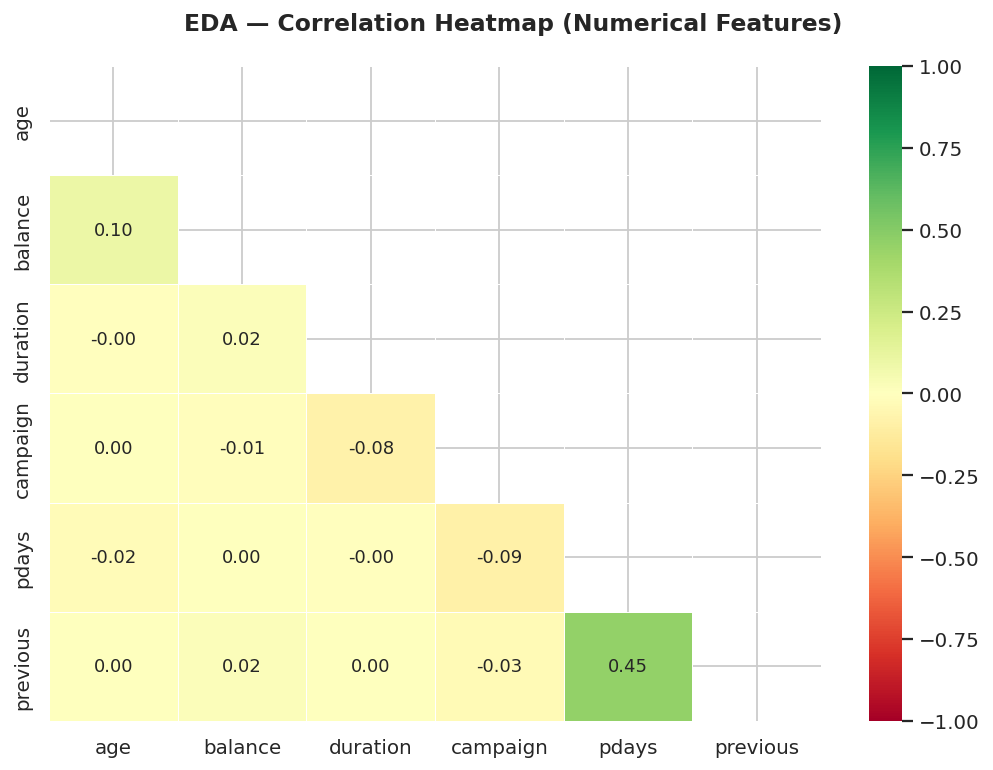

In [92]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle("EDA — Correlation Heatmap (Numerical Features)", fontsize=13, fontweight='bold')
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', mask=mask,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
plt.tight_layout()
plt.show()
plt.close()



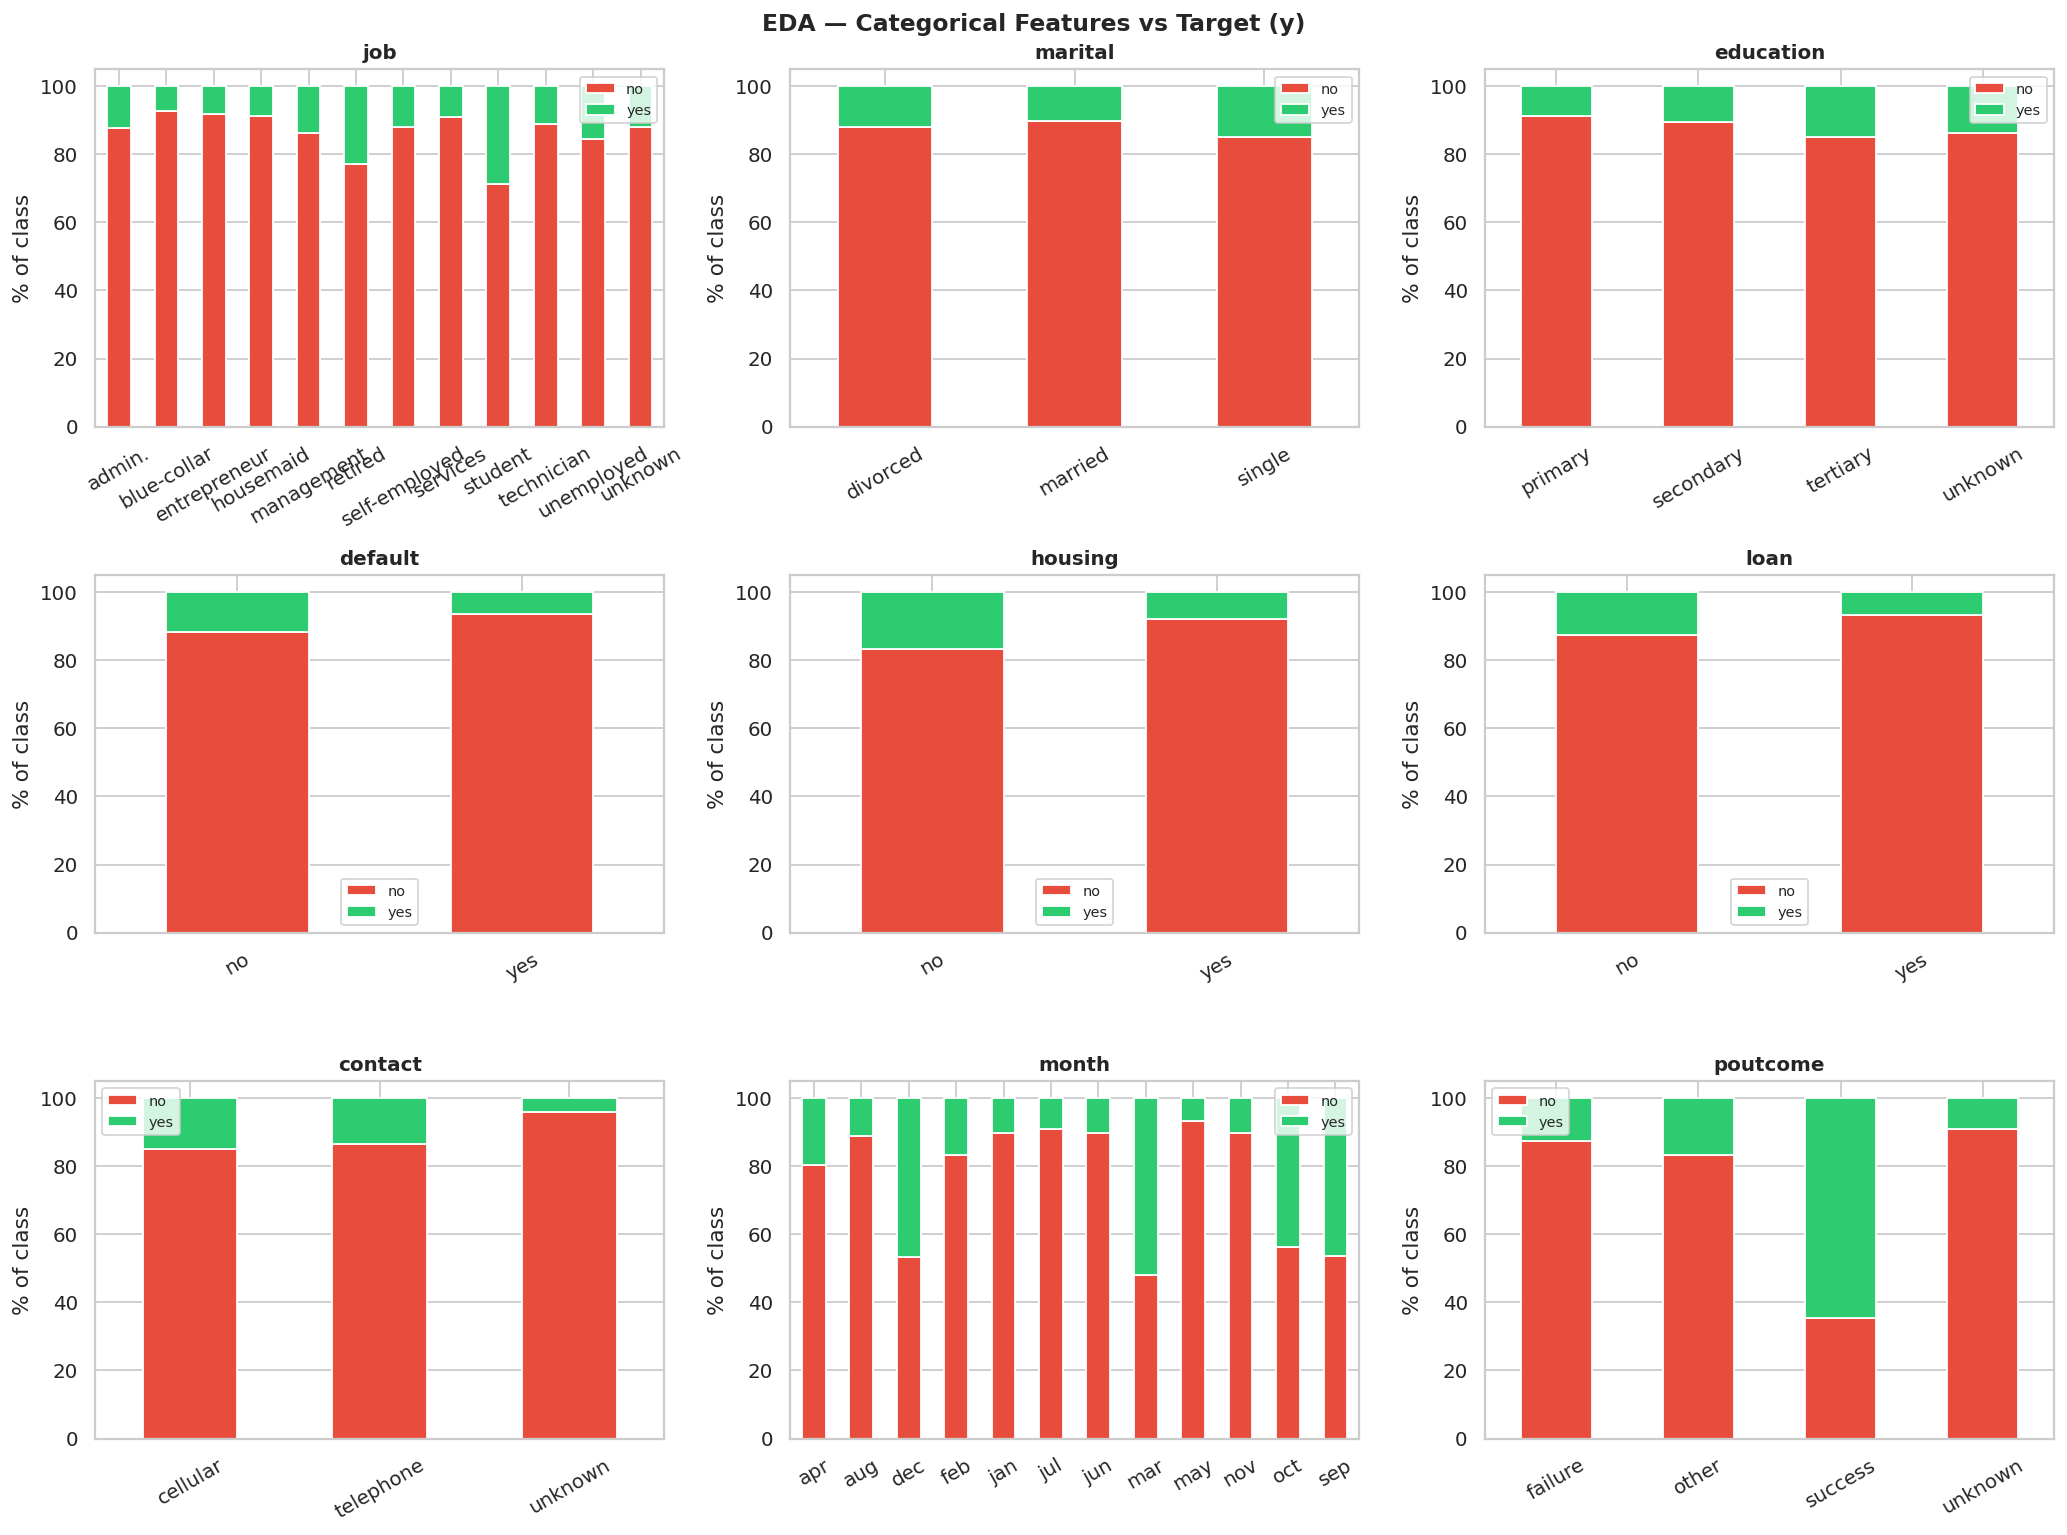

In [93]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("EDA — Categorical Features vs Target (y)", fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten(), cat_cols):
    ct = df.groupby(col)['y'].value_counts(normalize=True).unstack().fillna(0) * 100
    ct[['no','yes']].plot(kind='bar', stacked=True, ax=ax,
                          color=['#e74c3c','#2ecc71'], edgecolor='white')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel("% of class")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
plt.close()


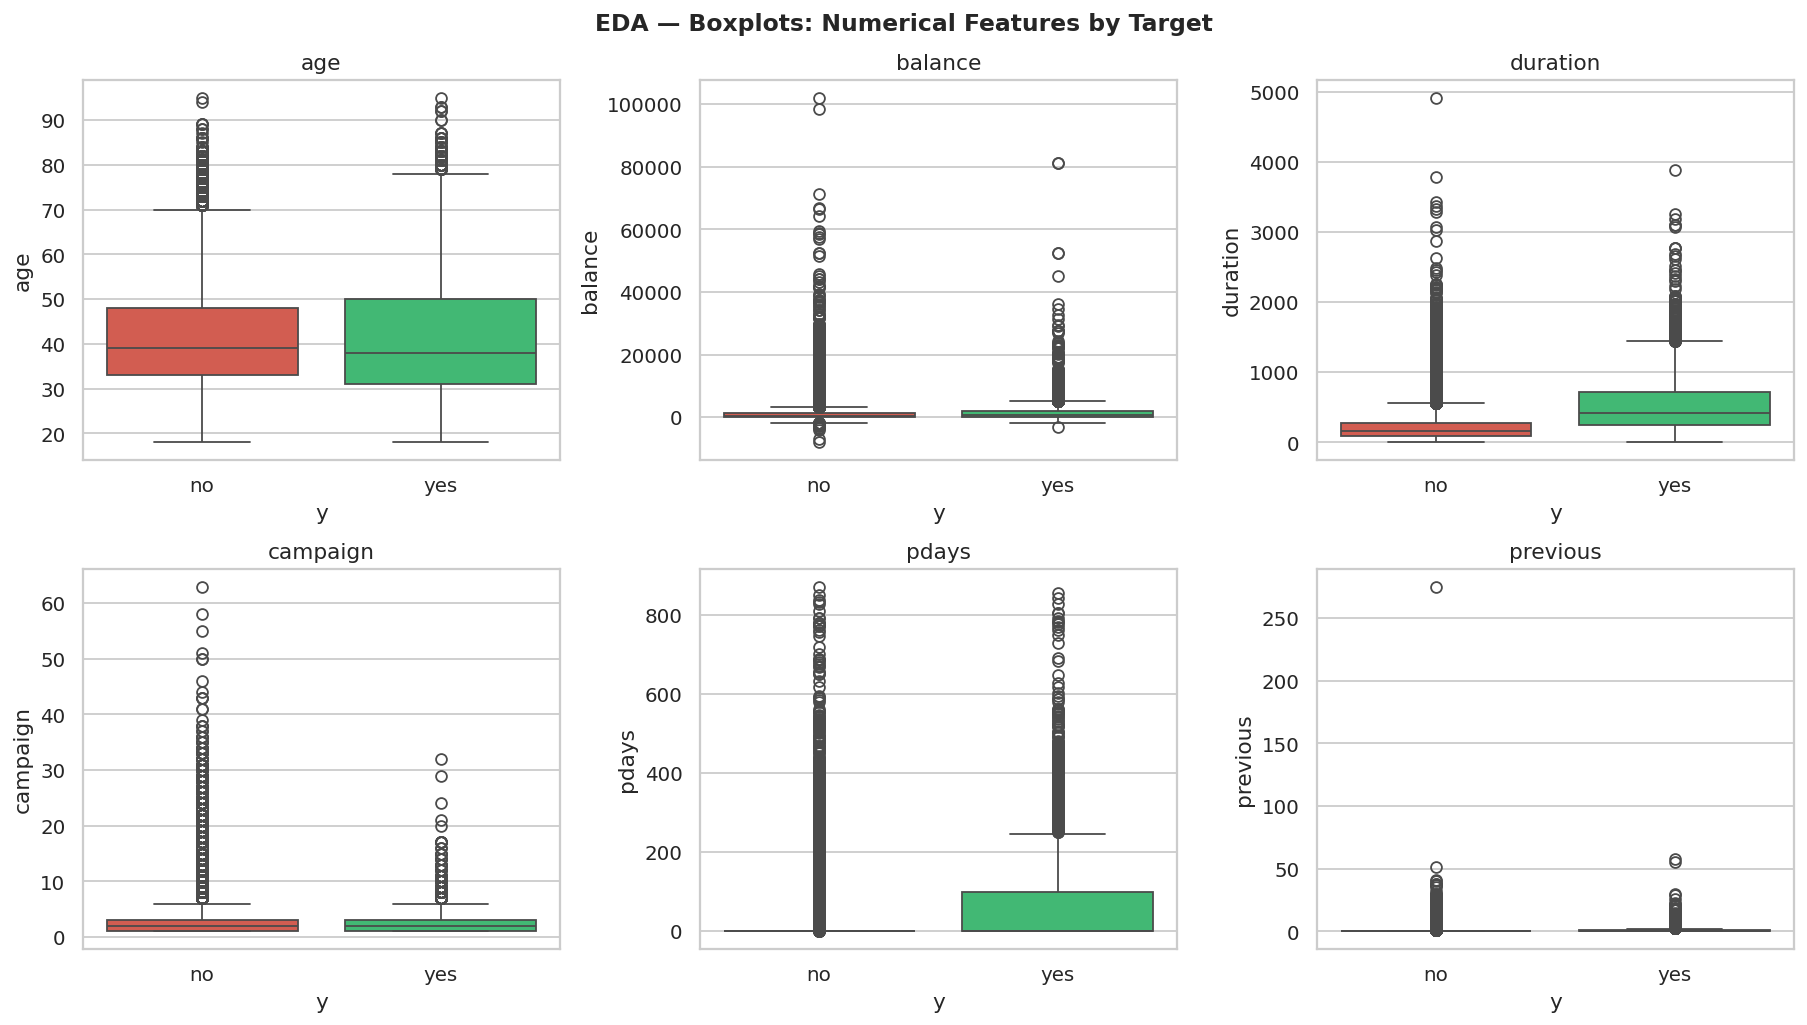

In [94]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("EDA — Boxplots: Numerical Features by Target", fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(data=df, x='y', y=col, palette={'no':'#e74c3c','yes':'#2ecc71'}, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()
plt.close()



In [95]:

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split



In [96]:
print("\nRemove Duplicates")
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"   Rows before: {before:,}  |  After: {after:,}  |  Removed: {before-after}")



Remove Duplicates
   Rows before: 45,211  |  After: 45,211  |  Removed: 0


In [97]:
print("\n Handle 'unknown' Category Values")
cols_with_unknown = ['job', 'education', 'contact', 'poutcome']
for col in cols_with_unknown:
    n_unknown = (df[col] == 'unknown').sum()
    if n_unknown > 0:
        mode_val = df[df[col] != 'unknown'][col].mode()[0]
        df[col] = df[col].replace('unknown', mode_val)
        print(f"   [{col}]  {n_unknown:,} unknowns → replaced with mode '{mode_val}'")


 Handle 'unknown' Category Values
   [job]  288 unknowns → replaced with mode 'blue-collar'
   [education]  1,857 unknowns → replaced with mode 'secondary'
   [contact]  13,020 unknowns → replaced with mode 'cellular'
   [poutcome]  36,959 unknowns → replaced with mode 'failure'


In [98]:
print("\n Fix 'pdays' Sentinel Value (-1 means never contacted)")
df['was_previously_contacted'] = (df['pdays'] != -1).astype(int)
df['pdays'] = df['pdays'].replace(-1, 0)
contact_rate = df['was_previously_contacted'].mean() * 100
print(f"   Created 'was_previously_contacted' flag")
print(f"   {contact_rate:.1f}% of clients were previously contacted")


 Fix 'pdays' Sentinel Value (-1 means never contacted)
   Created 'was_previously_contacted' flag
   18.3% of clients were previously contacted


In [99]:
print("\n Outlier Capping using IQR Method")
outlier_cols = ['balance', 'duration', 'campaign', 'previous']

for col in outlier_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower, upper)
    print(f"   [{col}]  {n_outliers:,} outliers capped  [range: {lower:.0f} – {upper:.0f}]")


 Outlier Capping using IQR Method
   [balance]  4,729 outliers capped  [range: -1962 – 3462]
   [duration]  3,235 outliers capped  [range: -221 – 643]
   [campaign]  3,064 outliers capped  [range: -2 – 6]
   [previous]  8,257 outliers capped  [range: 0 – 0]


In [100]:
print("\nFeature Engineering")

# Age groups → captures non-linear age effects
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 100],
                         labels=['<25', '25-35', '35-45', '45-55', '55+'])

# High balance flag → people with high savings may behave differently
df['high_balance'] = (df['balance'] > df['balance'].quantile(0.75)).astype(int)

# Month to season → reduces cardinality, captures seasonal patterns
season_map = {'dec': 'winter', 'jan': 'winter', 'feb': 'winter',
              'mar': 'spring', 'apr': 'spring', 'may': 'spring',
              'jun': 'summer', 'jul': 'summer', 'aug': 'summer',
              'sep': 'autumn', 'oct': 'autumn', 'nov': 'autumn'}
df['season'] = df['month'].map(season_map)

print("   Created: 'age_group'  (5-level binned age)")
print("   Created: 'high_balance'  (top 25% balance flag)")
print("   Created: 'season'  (month → season mapping)")


Feature Engineering
   Created: 'age_group'  (5-level binned age)
   Created: 'high_balance'  (top 25% balance flag)
   Created: 'season'  (month → season mapping)


In [101]:
print("\nEncode Target Variable (y)")
df['y'] = (df['y'] == 'yes').astype(int)
print(f"   'no' → 0  |  'yes' → 1")
print(f"   Class counts: {dict(df['y'].value_counts())}")


Encode Target Variable (y)
   'no' → 0  |  'yes' → 1
   Class counts: {0: np.int64(39922), 1: np.int64(5289)}


In [115]:
print("\nEncode Categorical Features")

# Binary columns → label encode (0/1)
binary_cols = ['default', 'housing', 'loan']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    print(f"   [{col}]  → binary encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}")


Encode Categorical Features
   [default]  → binary encoded: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
   [housing]  → binary encoded: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
   [loan]  → binary encoded: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}


In [103]:
print("\nEncode Categorical Features")

# Binary columns → label encode (0/1)
binary_cols = ['default', 'housing', 'loan']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    print(f"   [{col}]  → binary encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}")


# Ordinal columns → manual mapping
education_order = {'primary': 0, 'secondary': 1, 'tertiary': 2}
df['education'] = df['education'].map(education_order).fillna(1)
print(f"   [education] → ordinal: primary=0, secondary=1, tertiary=2")
# Nominal columns with 2–4 levels → One-Hot Encode
nominal_cols = ['job', 'marital', 'contact', 'poutcome', 'age_group', 'season']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
print(f"   [{', '.join(nominal_cols)}]  → One-Hot Encoded (drop_first=True)")

# Drop high-cardinality redundant column (month already mapped to season)
df.drop(columns=['month'], inplace=True, errors='ignore')
print("   [month] dropped (already encoded as 'season')")



Encode Categorical Features
   [default]  → binary encoded: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
   [housing]  → binary encoded: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
   [loan]  → binary encoded: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
   [education] → ordinal: primary=0, secondary=1, tertiary=2
   [job, marital, contact, poutcome, age_group, season]  → One-Hot Encoded (drop_first=True)
   [month] dropped (already encoded as 'season')


In [104]:
print("\nTrain / Test Split (80% / 20%, stratified)")
X = df.drop(columns=['y'])
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"   X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"   Train class distribution: {dict(y_train.value_counts())}")
print(f"   Test  class distribution: {dict(y_test.value_counts())}")




Train / Test Split (80% / 20%, stratified)
   X_train: (36168, 35)  |  X_test: (9043, 35)
   Train class distribution: {0: np.int64(31937), 1: np.int64(4231)}
   Test  class distribution: {0: np.int64(7985), 1: np.int64(1058)}


In [105]:
print("\nFeature Scaling (StandardScaler — fit on train only)")
num_features = ['age', 'balance', 'duration', 'campaign',
                'pdays', 'previous', 'day']
scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features]  = scaler.transform(X_test[num_features])
print(f"   Scaled: {num_features}")
print("    Fitted scaler on TRAIN only — no data leakage!")


Feature Scaling (StandardScaler — fit on train only)
   Scaled: ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day']
    Fitted scaler on TRAIN only — no data leakage!


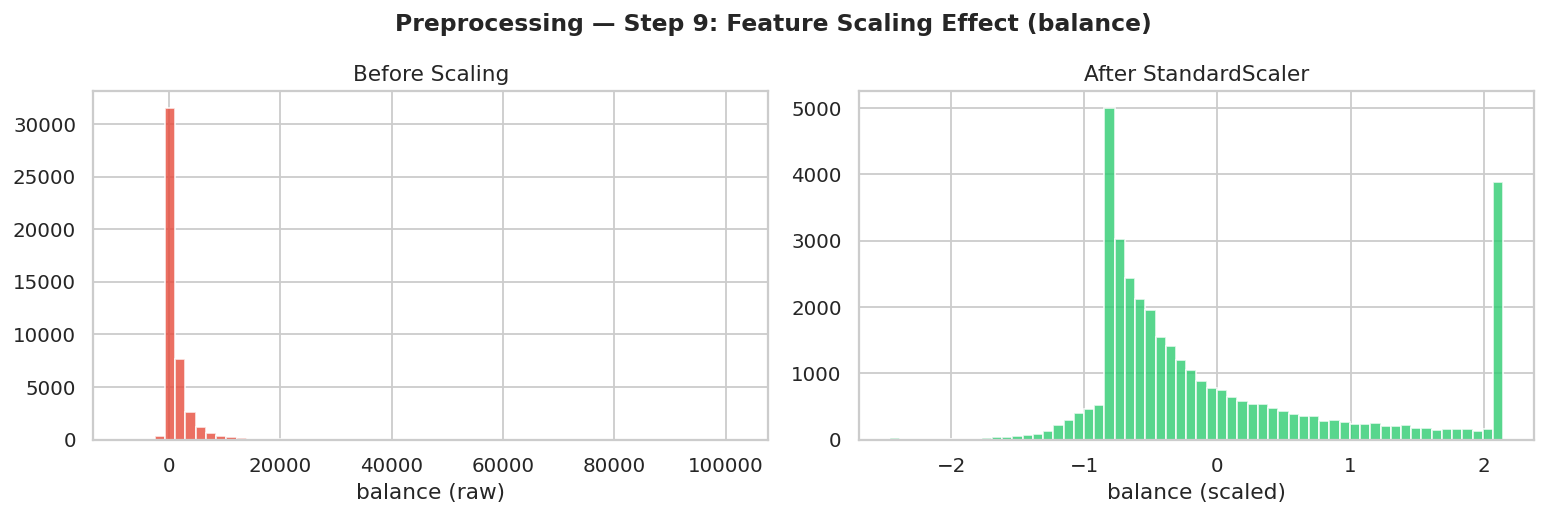


 PREPROCESSING COMPLETE
   Final feature count: 35
   Final columns: ['age', 'education', 'default', 'balance', 'housing', 'loan', 'day', 'duration', 'campaign', 'pdays', 'previous', 'was_previously_contacted', 'high_balance', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_married', 'marital_single', 'contact_telephone', 'poutcome_other', 'poutcome_success', 'age_group_25-35', 'age_group_35-45', 'age_group_45-55', 'age_group_55+', 'season_spring', 'season_summer', 'season_winter']


In [106]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Preprocessing — Step 9: Feature Scaling Effect (balance)", fontsize=13, fontweight='bold')

original_balance = pd.read_csv('/content/drive/MyDrive/Bank_LG_PROB/bank-full.csv', sep=';')['balance']
axes[0].hist(original_balance, bins=60, color='#e74c3c', alpha=0.8)
axes[0].set_title("Before Scaling")
axes[0].set_xlabel("balance (raw)")

axes[1].hist(X_train['balance'], bins=60, color='#2ecc71', alpha=0.8)
axes[1].set_title("After StandardScaler")
axes[1].set_xlabel("balance (scaled)")

plt.tight_layout()
plt.show()
plt.close()


print(f"\n PREPROCESSING COMPLETE")
print(f"   Final feature count: {X_train.shape[1]}")
print(f"   Final columns: {list(X_train.columns)}")

In [107]:
# Save processed datasets for Part 3 (Google Colab)
X_train.to_csv('/content/X_train.csv', index=False)
X_test.to_csv('/content/X_test.csv', index=False)
y_train.to_csv('/content/y_train.csv', index=False)
y_test.to_csv('/content/y_test.csv', index=False)

print("💾 Saved X_train, X_test, y_train, y_test to /content/")

💾 Saved X_train, X_test, y_train, y_test to /content/


In [108]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_recall_curve, average_precision_score
)
from sklearn.model_selection import cross_val_score

In [109]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',   # compensates for 7.5:1 imbalance
        solver='lbfgs',
        C=0.1,
        random_state=42
    )
}

In [116]:
for name in models:
    print(f"   ✔  {name}")

print("\n5-Fold Cross-Validation (ROC-AUC on training data)")
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train,
                             cv=5, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"   {name:25s}  AUC = {scores.mean():.4f} ± {scores.std():.4f}")


   ✔  Logistic Regression

5-Fold Cross-Validation (ROC-AUC on training data)
   Logistic Regression        AUC = 0.8878 ± 0.0046


In [111]:
print("\nTraining on full training set...")
trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
    print(f"   {name} trained")


Training on full training set...
   Logistic Regression trained


In [112]:
print("\nTest Set Evaluation")
print("-" * 60)
metrics_summary = []

for name, model in trained.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)
    pr_auc  = average_precision_score(y_test, y_proba)
    f1      = f1_score(y_test, y_pred)

    print(f"\n  ── {name} ──")
    print(classification_report(y_test, y_pred, target_names=['No (0)', 'Yes (1)']))
    print(f"  ROC-AUC Score     : {auc:.4f}")
    print(f"  PR-AUC Score      : {pr_auc:.4f}")

    metrics_summary.append({
        'Model': name,
        'F1 (yes)': round(f1, 4),
        'ROC-AUC': round(auc, 4),
        'PR-AUC': round(pr_auc, 4),
    })

metrics_df = pd.DataFrame(metrics_summary).set_index('Model')
print("\nMETRICS SUMMARY TABLE:")
print(metrics_df.to_string())


Test Set Evaluation
------------------------------------------------------------

  ── Logistic Regression ──
              precision    recall  f1-score   support

      No (0)       0.97      0.82      0.89      7985
     Yes (1)       0.37      0.81      0.51      1058

    accuracy                           0.82      9043
   macro avg       0.67      0.82      0.70      9043
weighted avg       0.90      0.82      0.84      9043

  ROC-AUC Score     : 0.8875
  PR-AUC Score      : 0.5138

METRICS SUMMARY TABLE:
                     F1 (yes)  ROC-AUC  PR-AUC
Model                                         
Logistic Regression    0.5081   0.8875  0.5138


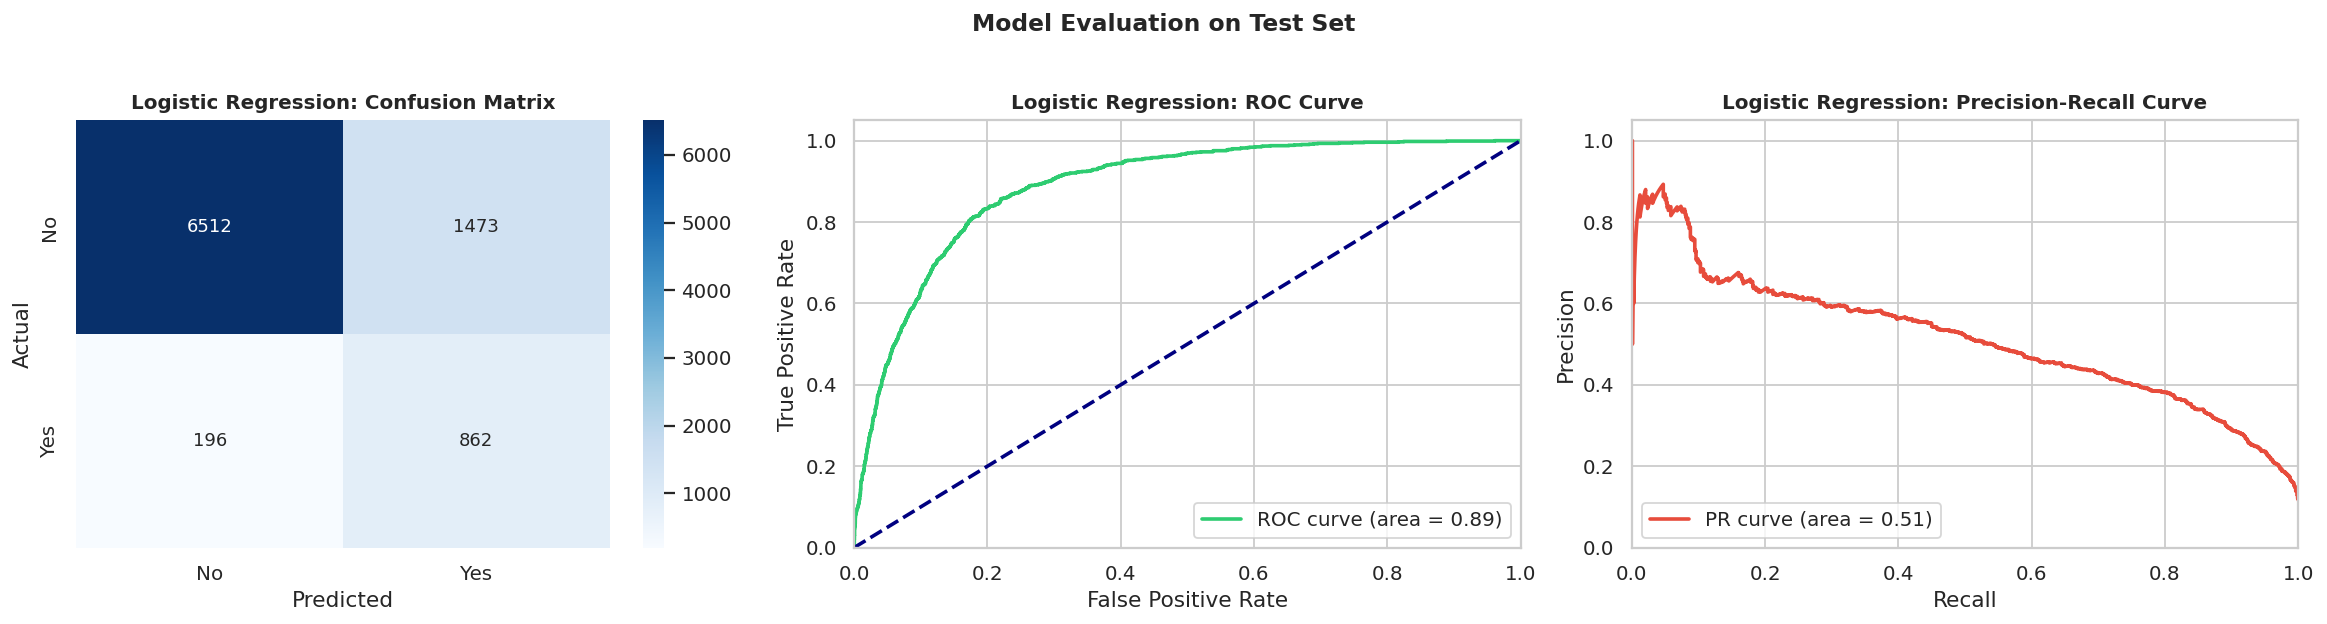

In [113]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Evaluation on Test Set", fontsize=13, fontweight='bold')

for name, model in trained.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'], ax=axes[0])
    axes[0].set_title(f"{name}: Confusion Matrix", fontsize=11, fontweight='bold')
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    axes[1].plot(fpr, tpr, color='#2ecc71', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f"{name}: ROC Curve", fontsize=11, fontweight='bold')
    axes[1].legend(loc="lower right")

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    axes[2].plot(recall, precision, color='#e74c3c', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
    axes[2].set_xlim([0.0, 1.0])
    axes[2].set_ylim([0.0, 1.05])
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].set_title(f"{name}: Precision-Recall Curve", fontsize=11, fontweight='bold')
    axes[2].legend(loc="lower left")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
plt.close()